In [35]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

Task-1 `MI80`

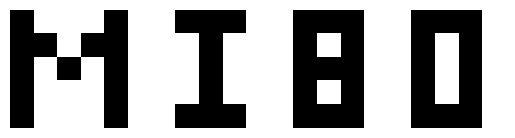

In [36]:
part1 = np.array([
    [0, 255, 255, 255, 0],
    [0, 0, 255, 0, 0],
    [0, 255, 0, 255, 0],
    [0, 255, 255, 255, 0],
    [0, 255, 255, 255, 0]
])
gap = np.array([
    [255],
    [255],
    [255],
    [255],
    [255]
])
part2 = np.array([
    [255, 0, 0, 0, 255],
    [255, 255, 0, 255, 255],
    [255, 255, 0, 255, 255],
    [255, 255, 0, 255, 255],
    [255, 0, 0, 0, 255]
])
part3 = np.array([
    [255, 0, 0, 0, 255],
    [255, 0, 255, 0, 255],
    [255, 0, 0, 0, 255],
    [255, 0, 255, 0, 255],
    [255, 0, 0, 0, 255]
])
part4 = np.array([
    [255, 0, 0, 0, 255],
    [255, 0, 255, 0, 255],
    [255, 0, 255, 0, 255],
    [255, 0, 255, 0, 255],
    [255, 0, 0, 0, 255]
])

combined = np.concatenate((part1, gap, part2, part3, part4), axis=1) # axis = 1 horizontal

plt.imshow(combined, cmap='gray')
plt.axis('off')
plt.show()

Task-2 `Transformation & Random Noise with histogram`

dataset: https://drive.google.com/drive/folders/1ixAuWWRrCK0SPwAIifmytnmNimCuTkpX?usp=sharing



In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
folder_path = '/content/drive/MyDrive/pics_for_463'
image_files = []
for f in os.listdir(folder_path):
    if f.lower().endswith('.jpg'):
        img_path = os.path.join(folder_path, f)
        img = cv2.imread(img_path)
        image_files.append(img)
print(len(image_files))

10



**All the transformations have been picked here because they are the most basic one's**

`rotation` - is used for rotating the image 90 degrees clockwise by using `cv2.getRotationMatrix2D()`. Here, rotation is done center, -90 degree angle and with 0.5 scale (could've been 1 or anything) and warpAffine() actually applies the geometric transformation.


---


Real life usecase: sometimes the pictures we take, their orientation is not right. So, to make it right we use rotation transformation

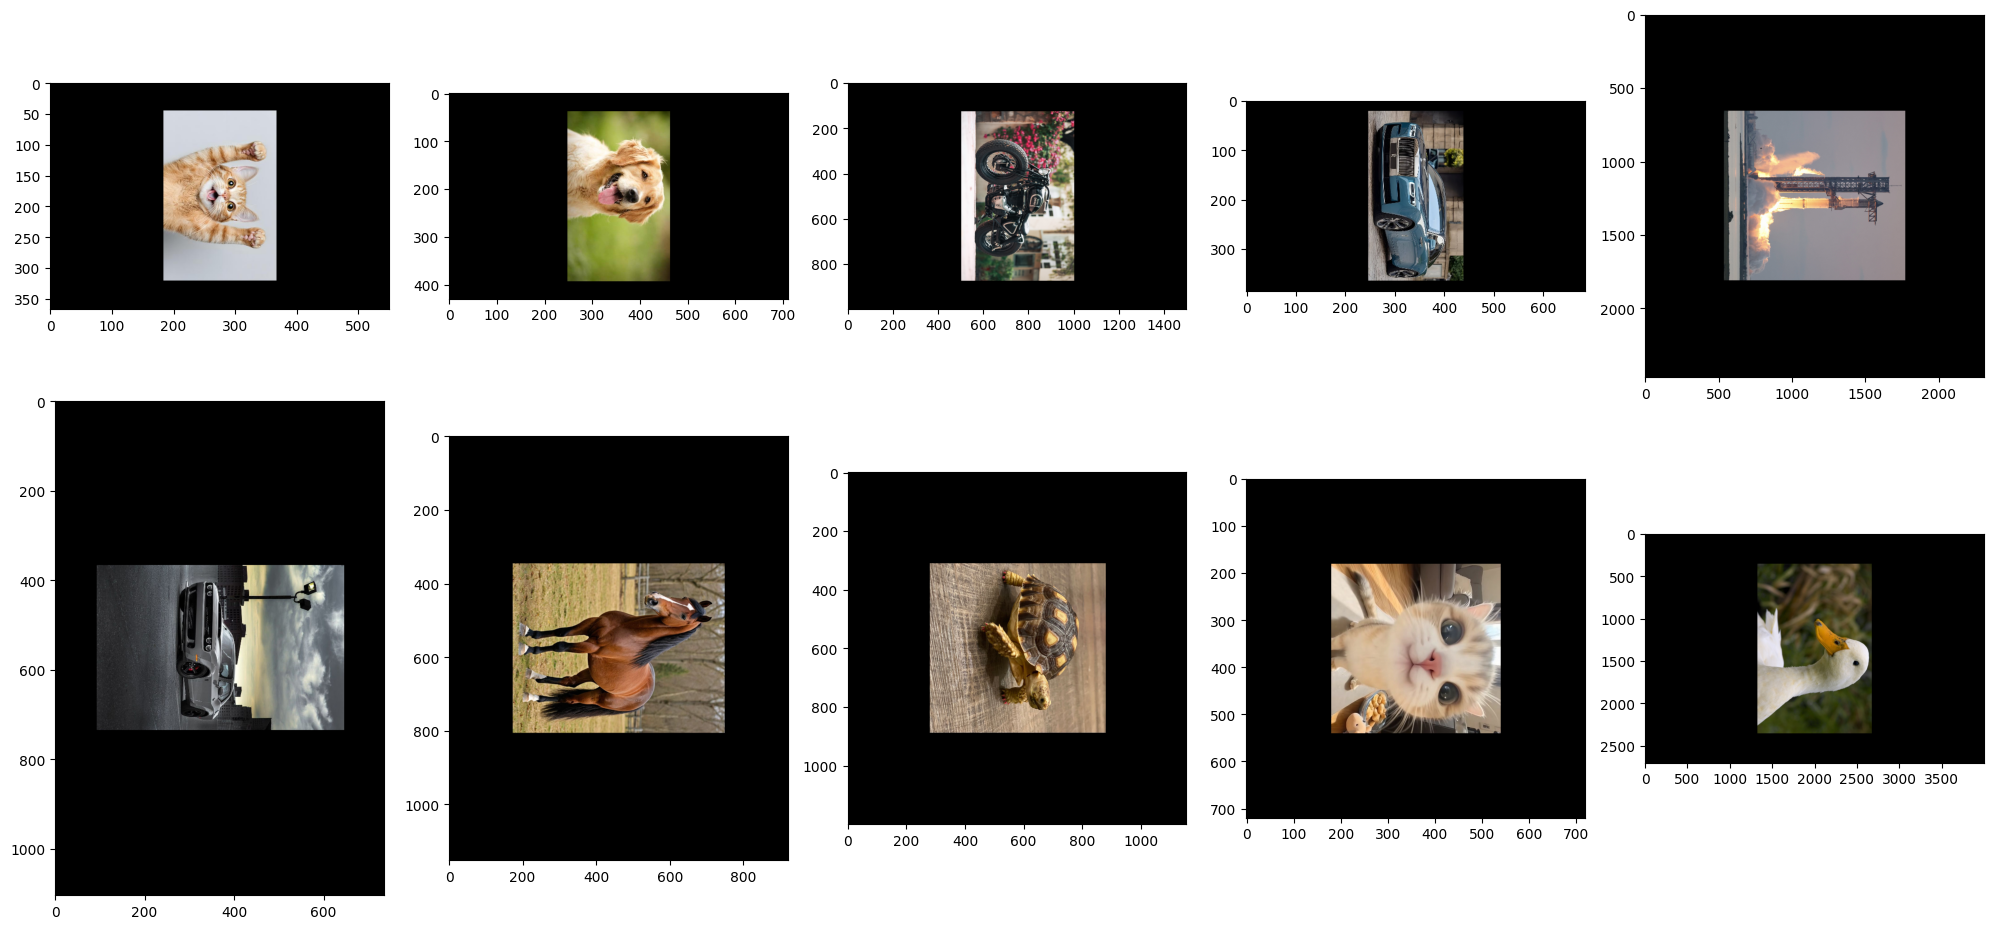

In [39]:
rotated_images = []
for i in image_files:
    rows, cols = i.shape[:2]
    M = cv2.getRotationMatrix2D((cols / 2, rows / 2), -90, 0.5)
    rotated = cv2.warpAffine(i, M, (cols, rows))
    rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)
    rotated_images.append(rotated_rgb)

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(rotated_images[i])

plt.tight_layout()
plt.show()


`resize` - it resizes/rescales the images by appling scaling of 1.5 to width and 1.5 to height meaning that it is done uniformly (it can be done non-uniformly as well). It uses resize() to reach it's aspired dimensions.

---
Real life usecase: If the images are too small or too big, it can be resized to desired proportion.


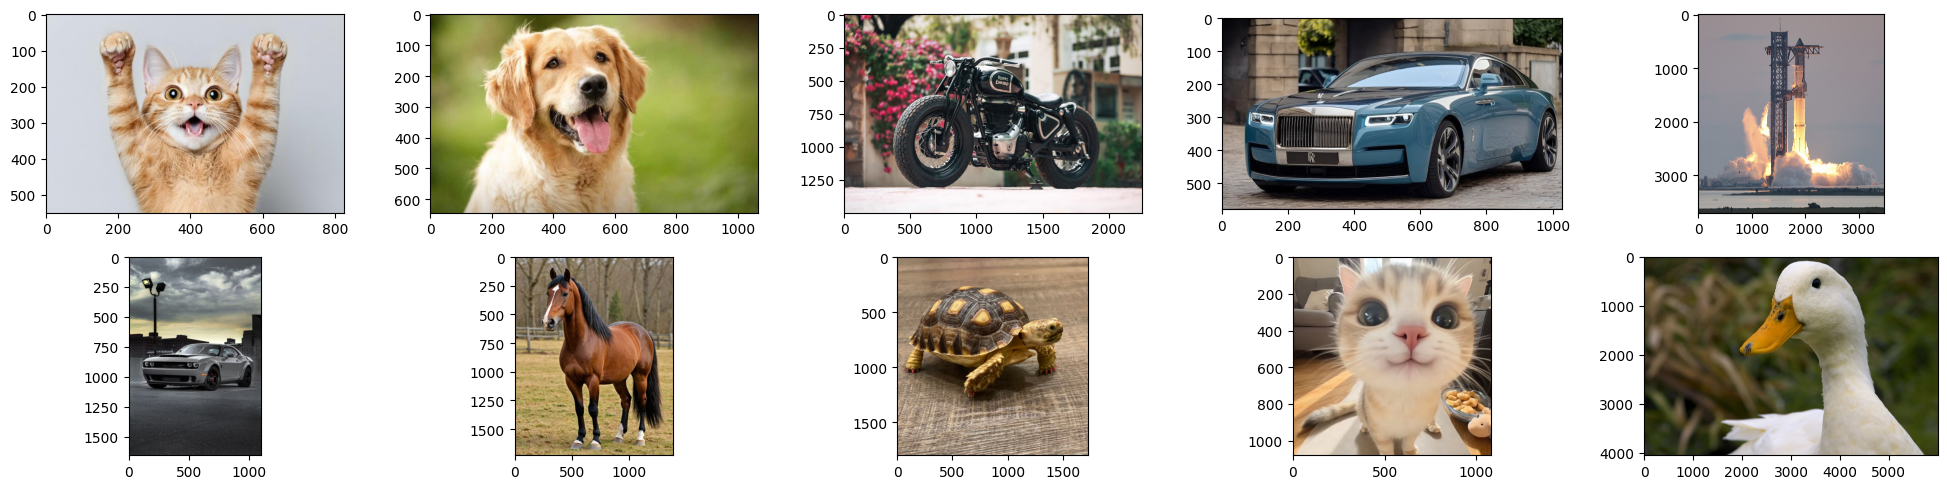

In [40]:
resized_images = []
for i in image_files:
    width = int(i.shape[1] * 1.5)
    height = int(i.shape[0] * 1.5)
    dim = (width, height)
    resized = cv2.resize(i, dim, interpolation=cv2.INTER_AREA)
    resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    resized_images.append(resized_rgb)

fig, axes = plt.subplots(2, 5, figsize=(20, 5))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(resized_images[i])

plt.tight_layout()
plt.show()

`translation` - is basically shifting the picture to it's designated coordinates of (x,y).

*   x (-ve) -> left
*   x (+ve) -> right
*   y (-ve) -> up
*   y (+ve) -> down
---
Real life usecase: for moving/sliding pictures after zooming in



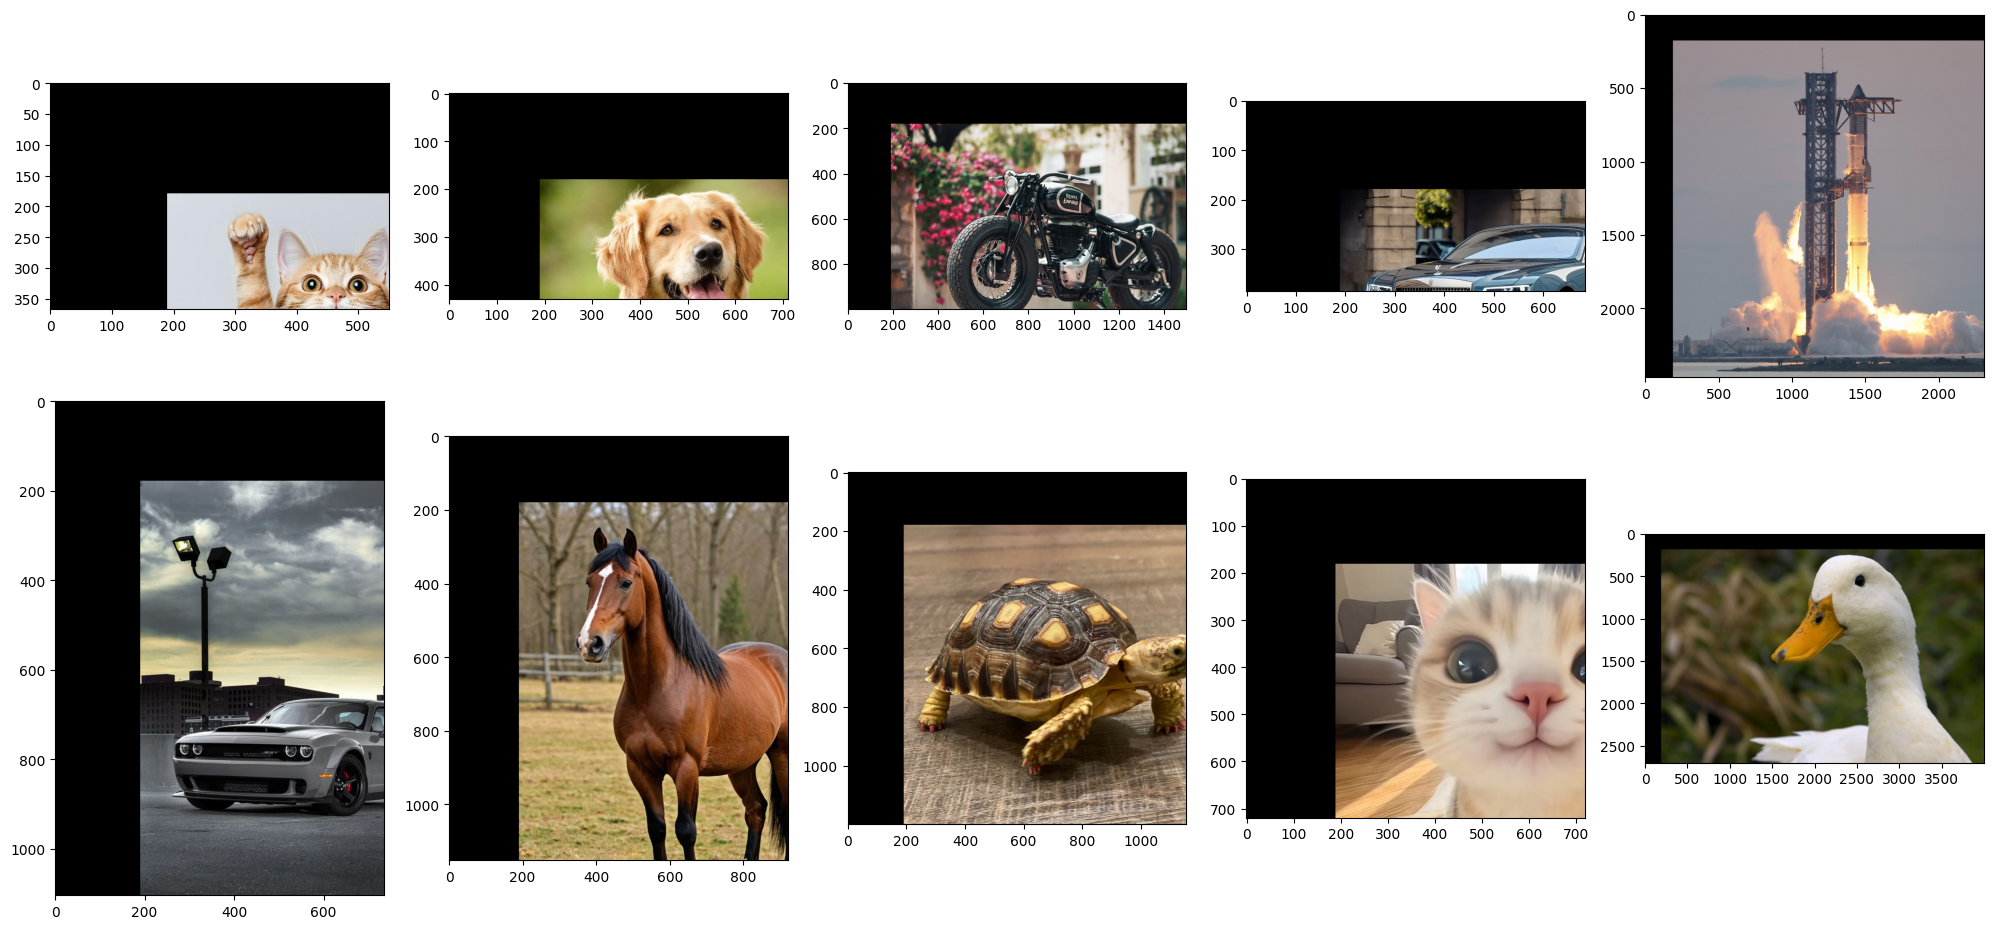

In [41]:
translated_images = []
shift_x = 190  # shift right by 50 pixels
shift_y = 180  # shift down by 30 pixels
translation_matrix = np.float32([[1, 0, shift_x],
                                 [0, 1, shift_y]])
for i in image_files:
    height = i.shape[0]
    width = i.shape[1]
    translated = cv2.warpAffine(i, translation_matrix, (width, height))
    translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)
    translated_images.append(translated_rgb)

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(translated_images[i])

plt.tight_layout()
plt.show()

`Shear` - it is used for changing perspective (skew). it can be used in any axis. Shear_matrix has been used to denote that the change of perspective along x-axis. Here no vertical (y) sheer has been done. Only horizontally (x), sheering has been done of the strength of 0.5

---

Real life usecase: when printing an uneven paper, it sometimes becomes skewed if not flattened properly.

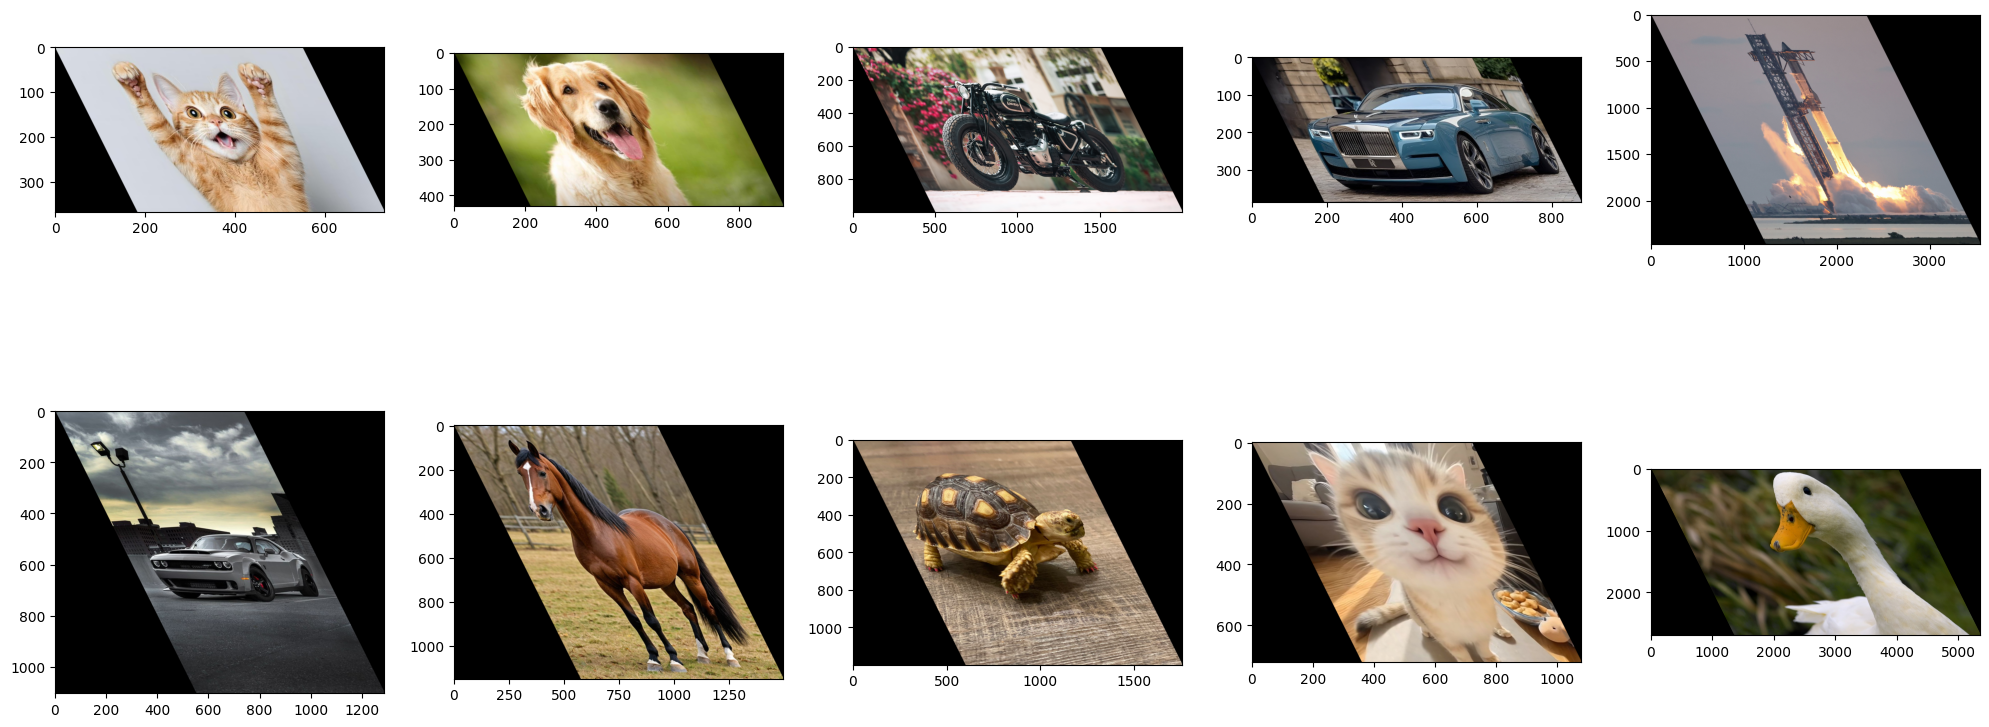

In [42]:
sheared_images = []
shear_x, shear_y = 0.5, 0.0
shear_matrix = np.float32([[1, shear_x, 0],
                           [shear_y, 1, 0]])

for i in image_files:
    h, w = i.shape[:2]
    sheared = cv2.warpAffine(i, shear_matrix, (w + int(shear_x * h), h))
    sheared_images.append(cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB))

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(sheared_images[i])

plt.tight_layout()
plt.show()

`stretch` - it's like scaling/resizing but only happens non-uniformly, meaning that proportions will be unnatural. It can be done along both axis denoted by stretch_x, stretch_y by using a stretch_matrix which will later be applied by using warpAffine()

---
Real life usecase: when we see a photo with different resolution in a 16:9 screen, it streches


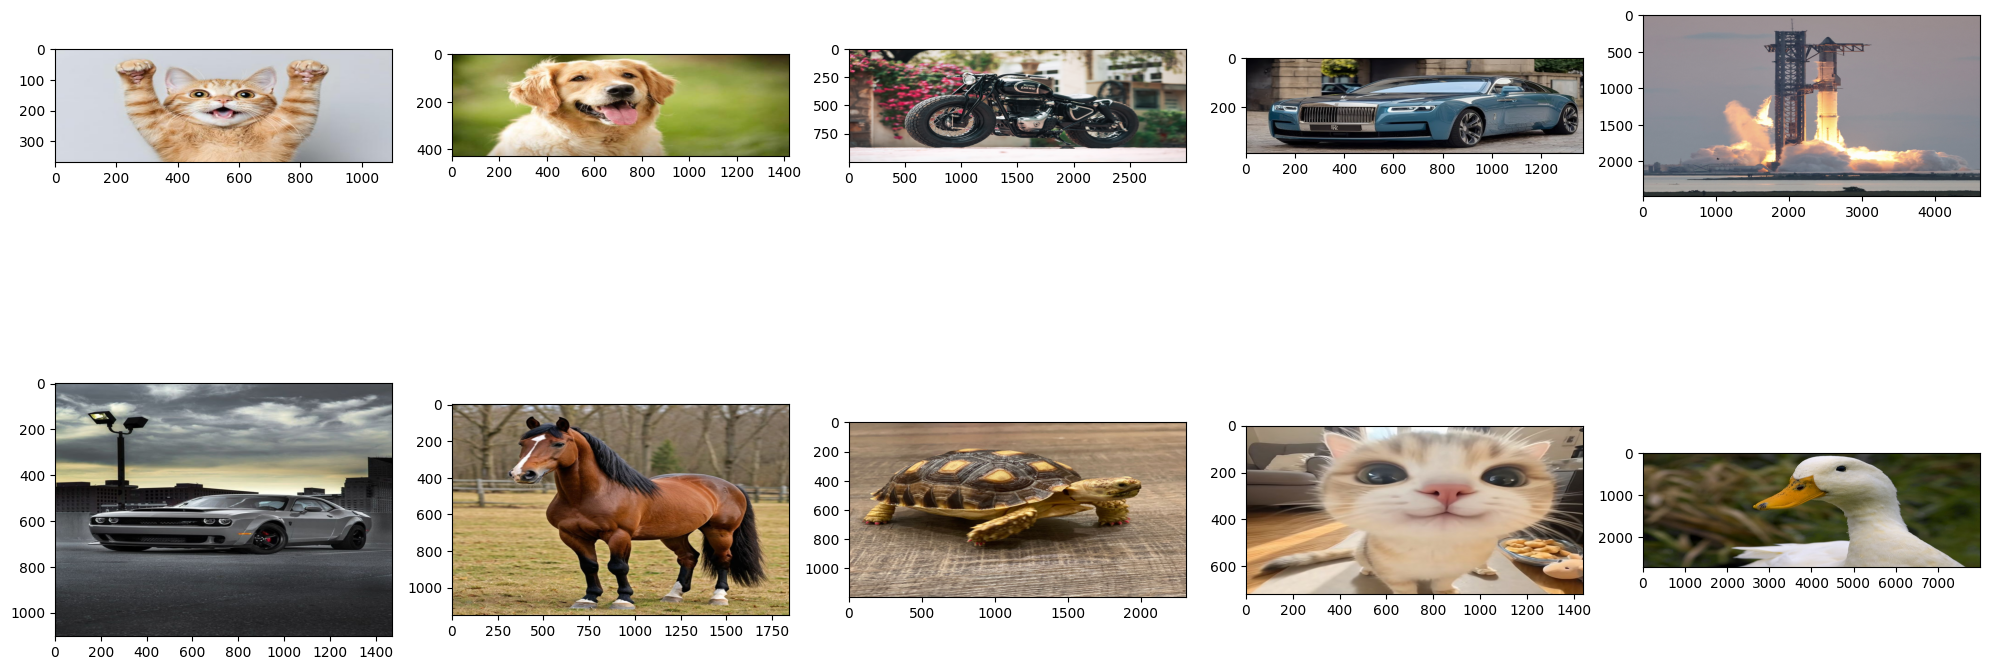

In [43]:
stretched_images = []
stretch_x, stretch_y = 2.0, 1.0
stretch_matrix = np.float32([[stretch_x, 0, 0],
                             [0, stretch_y, 0]])

for i in image_files:
    h, w = i.shape[:2]
    stretched = cv2.warpAffine(i, stretch_matrix, (int(w * stretch_x), int(h * stretch_y)))
    stretched_images.append(cv2.cvtColor(stretched, cv2.COLOR_BGR2RGB))

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(stretched_images[i])

plt.tight_layout()
plt.show()

noise


In [44]:
noisy_images = []
prob = 0.1

for imgs in image_files:
        noisy_image = np.copy(imgs)
        num_salt = np.ceil(prob * imgs.size * 0.5).astype(int)  # salt
        num_pepper = np.ceil(prob * imgs.size * 0.5).astype(int)  # pepper
        # salt - white
        coords = [np.random.randint(0, i - 1, num_salt) for i in imgs.shape]
        noisy_image[coords[0], coords[1]] = 255
        # pepper - black
        coords = [np.random.randint(0, i - 1, num_pepper) for i in imgs.shape]
        noisy_image[coords[0], coords[1]] = 0
        noisy_images.append(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title("Before")
        plt.axis("off")
        plt.imshow(cv2.cvtColor(imgs.astype(np.uint8), cv2.COLOR_BGR2RGB))

        plt.subplot(1, 2, 2)
        plt.title("After")
        plt.axis("off")
        plt.imshow(cv2.cvtColor(noisy_image.astype(np.uint8), cv2.COLOR_BGR2RGB))
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

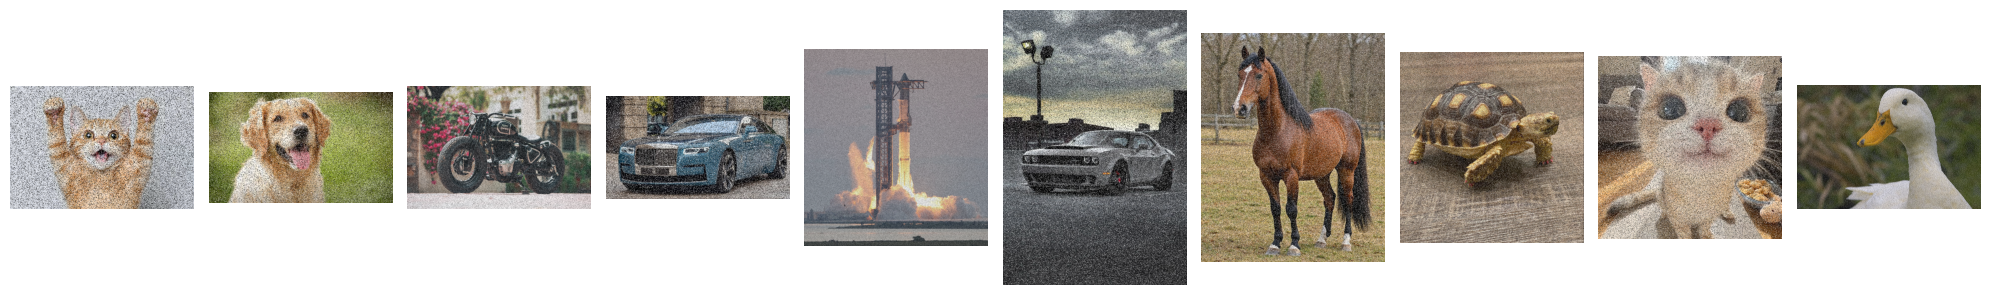

In [45]:
fig, axes = plt.subplots(1, 10, figsize=(20, 10))
axes = axes.flatten()
for i in range(10):
  axes[i].imshow(noisy_images[i])
  axes[i].axis('off')
plt.tight_layout()
plt.show()

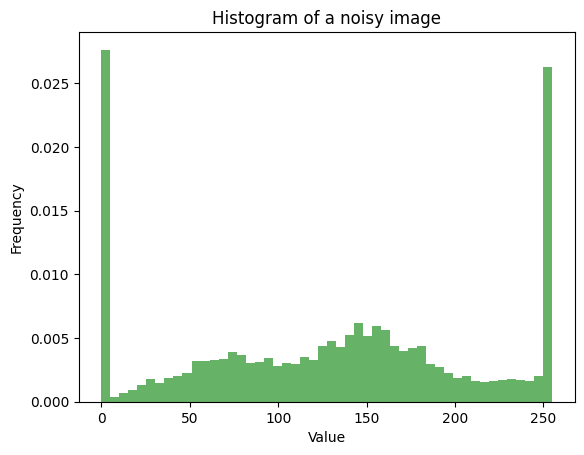

In [46]:
noisy_image = noisy_images[1]
flattened_noise = noisy_image.flatten()
plt.hist(flattened_noise, bins=50, density=True, alpha=0.6, color='g')
plt.title('Histogram of a noisy image')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

Task-3 `Blending pictures & adding Gaussian Noise with histogram`

dataset: https://drive.google.com/drive/folders/1as5o1A-8a2pSolTtXKp_6uW4dSsn4Mc-?usp=sharing

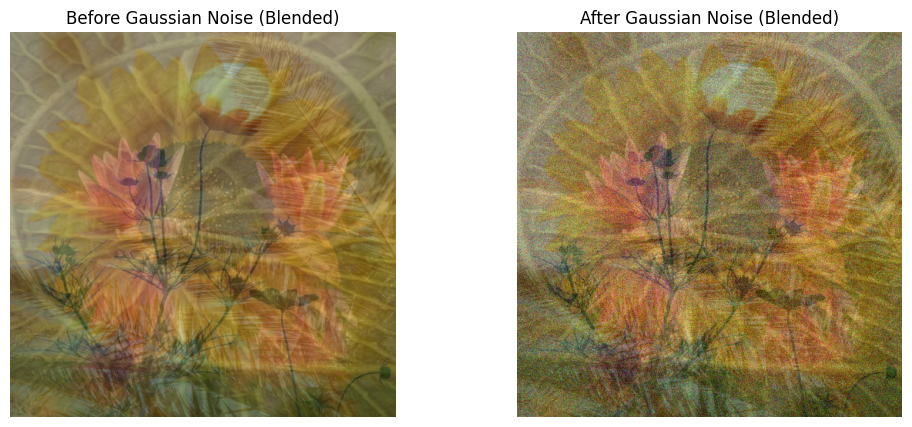

In [47]:
path = '/content/drive/MyDrive/pics_for_463/nature_dataset'
images = []
width, height = 500, 500
dim = (width, height)
for file in os.listdir(path):
    img_path = os.path.join(path, file)
    img = cv2.imread(img_path)
    img = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
    images.append(img)

alpha_list = [0.45, 0.6, 0.5, 0.7, 0.4]
total = sum(alpha_list)
for i in range(len(alpha_list)): # total of alpha would be 1
    alpha_list[i] /= total

result = np.zeros_like(images[0], dtype=np.float32)
for i in range(5):
    result += alpha_list[i] * images[i].astype(np.float32)
# print(result.min(), result.max())
result = result.astype(np.uint8)

mean = 0
std_dev = 20
gaussian_noise = np.random.normal(mean, std_dev, result.shape).astype(np.float32) # result.shape in place of sample number

noisy_img = cv2.add(result.astype(np.float32), gaussian_noise)
# print(noisy_img.min(), noisy_img.max())
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
# print(noisy_img.min(), noisy_img.max())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Before Gaussian Noise (Blended)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB))
plt.title("After Gaussian Noise (Blended)")
plt.axis("off")
plt.show()

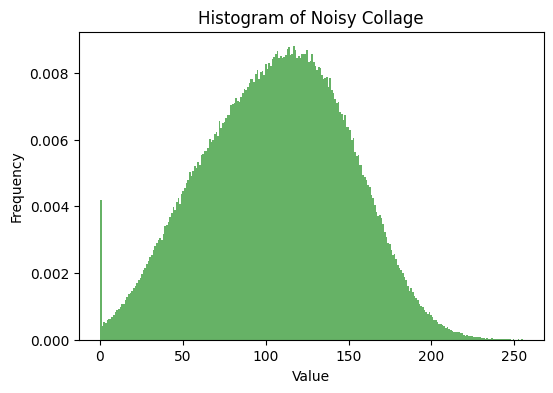

In [48]:
plt.figure(figsize=(6,4))
plt.hist(noisy_img.flatten(), bins=256, density=True, color='g', alpha=0.6)
# plt.hist(gaussian_noise.flatten(), bins=50, density=True, alpha=0.6, color='g')
plt.title('Histogram of Noisy Collage')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

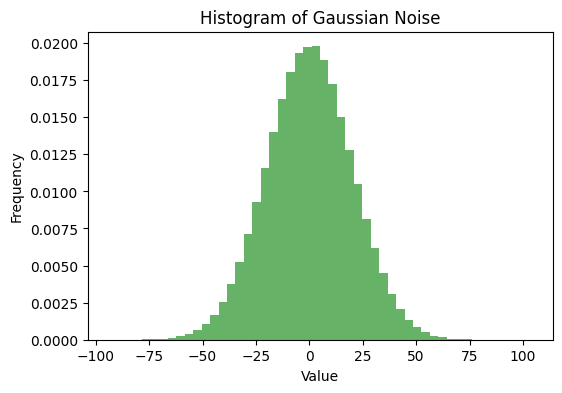

In [49]:
plt.figure(figsize=(6,4))
plt.hist(gaussian_noise.flatten(), bins=50, density=True, alpha=0.6, color='g')
plt.title('Histogram of Gaussian Noise')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()